In [1]:
# imports

import os
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
# base config

PROJECT_ROOT = Path("..").resolve()

DATA_ROOT = PROJECT_ROOT / "data/raw/messy_mashup"

GENRES_PATH = DATA_ROOT / "genres_stems"

FEATURE_SAVE_PATH = PROJECT_ROOT / "data/processed/stem_embeddings"
MEL_SAVE_PATH = PROJECT_ROOT / "data/processed/mel_spectrograms"

os.makedirs(FEATURE_SAVE_PATH, exist_ok=True)
os.makedirs(MEL_SAVE_PATH, exist_ok=True)

# assert all paths exist
assert GENRES_PATH.exists(), f"Genres path {GENRES_PATH} does not exist."
assert FEATURE_SAVE_PATH.exists(), f"Feature save path {FEATURE_SAVE_PATH} does not exist."
assert MEL_SAVE_PATH.exists(), f"Mel save path {MEL_SAVE_PATH} does not exist."

In [3]:
# sanity check: stem structure

genres = sorted(os.listdir(GENRES_PATH))
print(genres)

sample_genre = genres[0]
print(os.listdir(os.path.join(GENRES_PATH, sample_genre))[:5])

['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
['blues.00079', 'blues.00072', 'blues.00076', 'blues.00043', 'blues.00014']


In [4]:
# feature extraction

def extract_features(file):

    y, sr = librosa.load(file, sr=22050)

    features = {}

    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    features["mfcc_mean"] = np.mean(mfcc)
    features["mfcc_std"] = np.std(mfcc)

    # Spectral centroid
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features["spectral_centroid_mean"] = np.mean(centroid)

    # Zero crossing rate
    zcr = librosa.feature.zero_crossing_rate(y)
    features["zcr_mean"] = np.mean(zcr)

    # Chroma
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    features["chroma_mean"] = np.mean(chroma)

    # Spectral bandwidth
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features["bandwidth_mean"] = np.mean(bandwidth)

    # Spectral rolloff
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features["rolloff_mean"] = np.mean(rolloff)

    return features

In [5]:
# build feature dataset

records = []

for genre in genres:

    print(f"Processing {genre}...")

    genre_path = os.path.join(GENRES_PATH, genre)

    for track in tqdm(os.listdir(genre_path)):

        track_path = os.path.join(genre_path, track)

        if not os.path.isdir(track_path):
            continue

        for stem in os.listdir(track_path):

            if not stem.endswith(".wav"):
                continue

            stem_path = os.path.join(track_path, stem)

            try:

                feats = extract_features(stem_path)

                feats["genre"] = genre
                feats["stem"] = stem.replace(".wav","")
                feats["track"] = track

                records.append(feats)

            except:
                continue

df = pd.DataFrame(records)

df.head()

Processing blues...


  0%|          | 0/100 [00:00<?, ?it/s]/home/saber/IITM/DL-GenAI-Project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 48%|████▊     | 48/100 [00:38<00:43,  1.19it/s]/home/saber/IITM/DL-GenAI-Project/.venv/lib/python3.11/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
100%|██████████| 100/100 [01:21<00:00,  1.22it/s]


Processing classical...


100%|██████████| 100/100 [01:28<00:00,  1.13it/s]


Processing country...


...

Processing reggae...


100%|██████████| 100/100 [01:26<00:00,  1.16it/s]


Processing rock...


100%|██████████| 100/100 [01:25<00:00,  1.17it/s]


,mfcc_mean,mfcc_std,spectral_centroid_mean,zcr_mean,chroma_mean,bandwidth_mean,rolloff_mean,genre,stem,track
0,-3.318620,142.180954,165.302540,0.013253,0.344540,177.310526,230.645086,blues,bass,blues.00079
1,0.372484,53.986126,3170.775920,0.187855,0.476145,2553.494087,6235.885726,blues,drums,blues.00079
2,-40.582413,130.476349,4645.179635,0.402711,0.232373,1710.139466,6235.944014,blues,vocals,blues.00079
3,-19.384653,56.824818,2569.723105,0.180737,0.330338,2089.160290,4671.106325,blues,other,blues.00079
4,-18.427607,162.504684,334.929661,0.022432,0.357882,586.974966,564.159930,blues,bass,blues.00072


In [6]:
# save extracted features

feature_file = os.path.join(FEATURE_SAVE_PATH, "stem_features.csv")

df.to_csv(feature_file, index=False)

print("Saved features to:", feature_file)

Saved features to: /home/saber/IITM/DL-GenAI-Project/data/processed/stem_embeddings/stem_features.csv


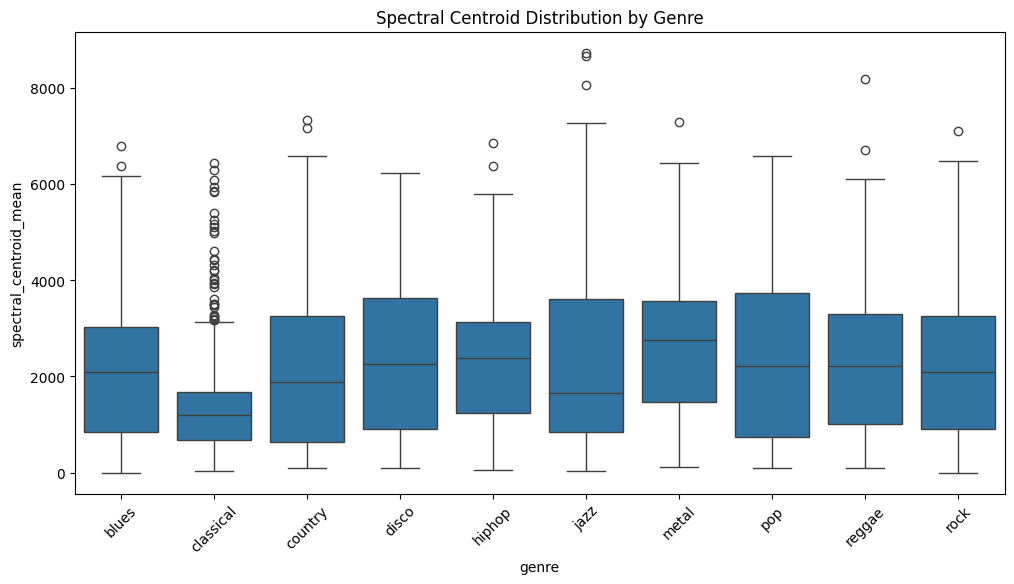

In [7]:
# feature distribuion

plt.figure(figsize=(12,6))

sns.boxplot(data=df, x="genre", y="spectral_centroid_mean")

plt.xticks(rotation=45)
plt.title("Spectral Centroid Distribution by Genre")

plt.show()

### Spectral Centroid Distribution by Genre

The spectral centroid represents the **perceived brightness of a sound**, indicating where the center of mass of the spectrum lies. Higher centroid values typically correspond to audio with stronger high-frequency components.

- Genres such as **metal, rock, and reggae** tend to exhibit higher spectral centroid values, reflecting the presence of **distorted guitars, cymbals, and high-energy instrumentation**.
- **Classical music** shows relatively lower centroid values, consistent with smoother timbres and orchestral instruments that emphasize lower and mid frequencies.
- **Jazz and hip-hop** display wider variability, likely due to the diversity of instrumentation and rhythmic patterns present in these genres.
- Several outliers are visible across genres, indicating tracks with unusually bright or sharp spectral characteristics.

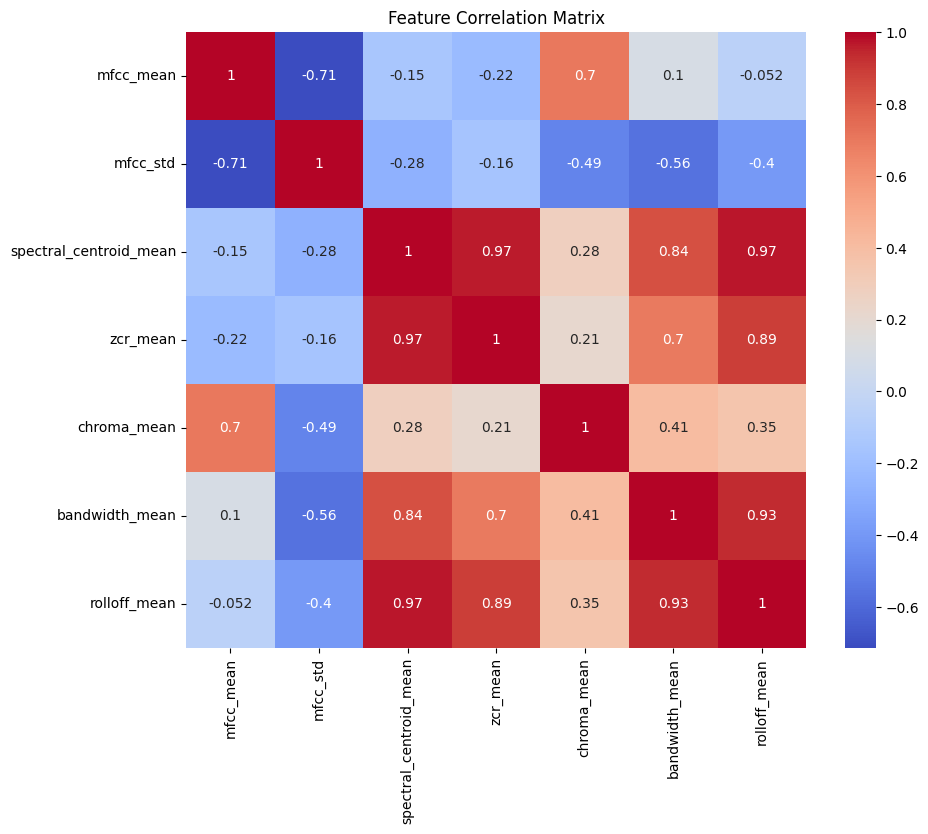

In [9]:
# feature correlation heatmap

plt.figure(figsize=(10,8))

corr = df.drop(columns=["genre","stem","track"]).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()

### Feature Correlation Matrix

- **Spectral centroid, rolloff, and bandwidth** exhibit very strong positive correlations. This is expected because all three features describe aspects of the **frequency distribution of the signal**.
- **Zero Crossing Rate (ZCR)** is also highly correlated with spectral centroid and rolloff, suggesting that signals with higher frequency content produce more waveform crossings.
- **MFCC mean and MFCC standard deviation** show a strong negative correlation, indicating complementary information between the average spectral envelope and its variability.
- **Chroma features** show moderate correlation with MFCC statistics, reflecting shared information about tonal structure.

The high correlation among spectral features indicates some **redundancy in the feature set**. While these features remain useful, dimensionality reduction techniques such as **PCA or deep feature learning** can help extract more compact representations.


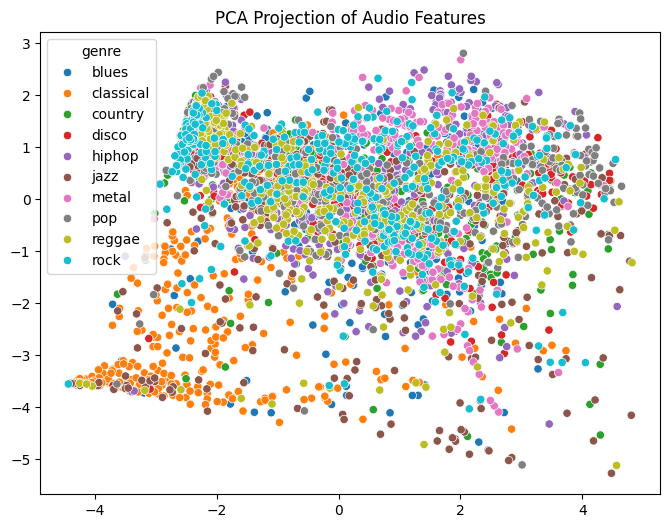

In [10]:
# pca visualization

X = df.drop(columns=["genre","stem","track"])
y = df["genre"]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette="tab10")

plt.title("PCA Projection of Audio Features")

plt.show()

### PCA Projection of Audio Features

Principal Component Analysis (PCA) reduces the high-dimensional feature space into two principal components that capture the largest variance in the data.

- Several genre clusters begin to appear, particularly for **classical and jazz**, which occupy more distinct regions of the feature space.
- However, many genres such as **pop, rock, disco, and reggae** show significant overlap.
- The spread of points indicates that musical genres share many similar acoustic characteristics.
- The overlap between genre clusters suggests that **linear feature projections are insufficient to fully separate genres** using simple handcrafted features.


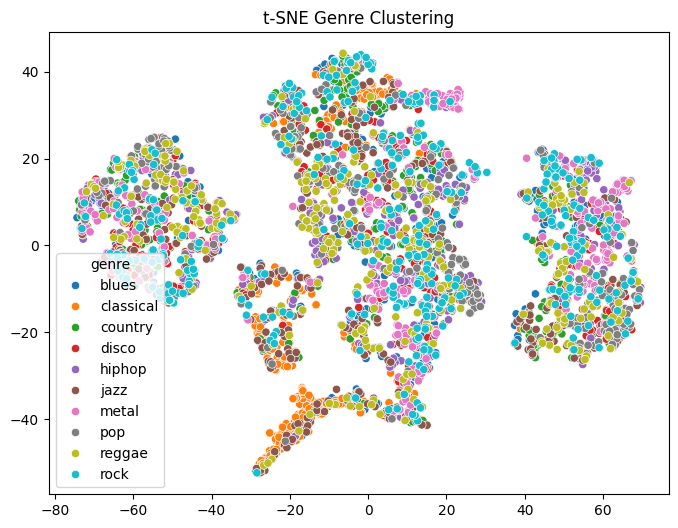

In [11]:
# t-sne visualization

tsne = TSNE(n_components=2, perplexity=40, random_state=42)

X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y, palette="tab10")

plt.title("t-SNE Genre Clustering")

plt.show()

### t-SNE Visualization of Genre Clustering

- Compared to PCA, t-SNE reveals **more distinct clusters** in the feature space.
- Certain genres such as **classical and jazz** appear more concentrated in specific regions.
- Some clusters still contain mixed genres, indicating that acoustic features alone may not fully distinguish all genres.


The improved clustering seen in the t-SNE projection suggests that the feature space contains **non-linear structures** that cannot be captured by linear techniques such as PCA.


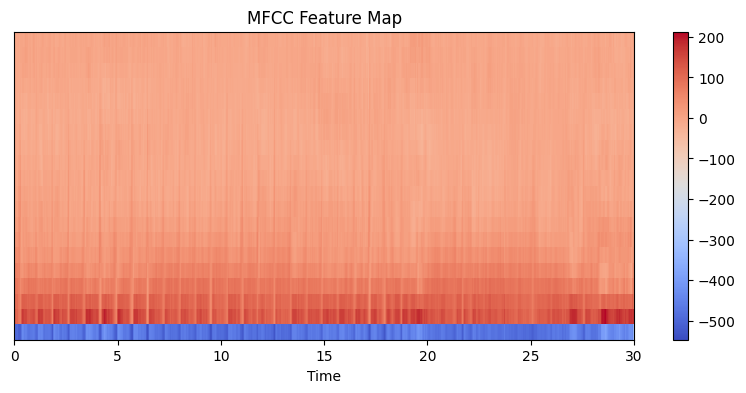

In [12]:
# mfcc heatmap 

sample = df.iloc[0]

sample_path = os.path.join(
    GENRES_PATH,
    sample["genre"],
    sample["track"],
    sample["stem"] + ".wav"
)

y, sr = librosa.load(sample_path)

mfcc = librosa.feature.mfcc(y=y, sr=sr)

plt.figure(figsize=(10,4))

librosa.display.specshow(mfcc, x_axis="time")

plt.colorbar()

plt.title("MFCC Feature Map")

plt.show()

### MFCC Feature Map

Mel-Frequency Cepstral Coefficients (MFCCs) represent the short-term spectral characteristics of audio signals and are widely used in speech and music analysis.


- The heatmap shows how MFCC values evolve across time.
- Lower MFCC coefficients capture the **overall spectral envelope**, while higher coefficients represent finer spectral variations.
- Temporal variations in MFCC values reflect changes in musical notes, rhythm, and instrumentation.


In [5]:
# saving mel spectrograms for training

def save_mel(file, save_path):

    y, sr = librosa.load(file, sr=22050)

    mel = librosa.feature.melspectrogram(y=y, sr=sr)

    mel_db = librosa.power_to_db(mel)

    np.save(save_path, mel_db)

for genre in genres:

    print(f"Processing {genre}...")

    genre_path = os.path.join(GENRES_PATH, genre)

    for track in tqdm(os.listdir(genre_path)):

        track_path = os.path.join(genre_path, track)

        if not os.path.isdir(track_path):
            continue

        for stem in os.listdir(track_path):

            if not stem.endswith(".wav"):
                continue

            stem_path = os.path.join(track_path, stem)

            save_name = f"{genre}_{track}_{stem}.npy"

            save_path = os.path.join(MEL_SAVE_PATH, save_name)

            try:
                save_mel(stem_path, save_path)
            except:
                continue

Processing blues...


  0%|          | 0/100 [00:00<?, ?it/s]/home/saber/IITM/DL-GenAI-Project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 100/100 [00:24<00:00,  4.13it/s]


Processing classical...


100%|██████████| 100/100 [00:26<00:00,  3.84it/s]


Processing country...


...

100%|██████████| 100/100 [00:25<00:00,  3.98it/s]


Processing reggae...


100%|██████████| 100/100 [00:24<00:00,  4.06it/s]


Processing rock...


100%|██████████| 100/100 [00:24<00:00,  4.08it/s]
